# Federated Learning Communication Efficiency Research
## Testing Different Communication Rounds (τ)

**Research Question:** How does the number of communication rounds (τ) affect FL efficiency?

**Variables:**
- Independent: τ ∈ {1, 5, 10, 20, 50}
- Dependent: Communication cost (bits), Accuracy (90% threshold), Convergence round, Training time

---

## 1. Setup & Installation

Run this first to install dependencies and check GPU availability.

In [1]:
# Check GPU
!nvidia-smi

# Install required packages (most should already be in Colab)
!pip install torch torchvision matplotlib seaborn -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, Subset
import torchvision
import torchvision.transforms as transforms
import numpy as np
import time
import copy
import json
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Check device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n{'='*60}")
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"{'='*60}\n")

Wed Dec 10 15:38:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Model & Client/Server Implementation

In [2]:
class SimpleCNN(nn.Module):
    """Simple CNN for MNIST"""
    def __init__(self, num_classes=10, input_channels=1):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(input_channels, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class FederatedClient:
    """Federated Learning Client"""
    def __init__(self, client_id: int, train_data: Dataset, device: str):
        self.client_id = client_id
        self.train_data = train_data
        self.device = device
        self.model = None

    def set_model(self, model: nn.Module):
        """Set the global model"""
        self.model = copy.deepcopy(model).to(self.device)

    def train(self, epochs: int, batch_size: int, learning_rate: float) -> Tuple[Dict, float]:
        """Train local model for specified epochs"""
        self.model.train()
        optimizer = optim.SGD(self.model.parameters(), lr=learning_rate, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        train_loader = DataLoader(self.train_data, batch_size=batch_size, shuffle=True)

        total_computation_time = 0

        for epoch in range(epochs):
            epoch_start = time.time()
            for data, target in train_loader:
                data, target = data.to(self.device), target.to(self.device)
                optimizer.zero_grad()
                output = self.model(data)
                loss = criterion(output, target)
                loss.backward()
                optimizer.step()
            total_computation_time += time.time() - epoch_start

        model_params = {name: param.cpu().clone() for name, param in self.model.named_parameters()}

        return model_params, total_computation_time


class FederatedServer:
    """Federated Learning Server"""
    def __init__(self, model: nn.Module, test_data: Dataset, device: str):
        self.global_model = model.to(device)
        self.test_data = test_data
        self.device = device

    def aggregate(self, client_params_list: List[Dict], client_weights: List[float]):
        """FedAvg: Aggregate client models"""
        global_params = self.global_model.state_dict()

        for key in global_params.keys():
            if 'weight' in key or 'bias' in key:
                global_params[key] = torch.zeros_like(global_params[key])
                for client_params, weight in zip(client_params_list, client_weights):
                    global_params[key] += client_params[key].to(self.device) * weight

        self.global_model.load_state_dict(global_params)

    def evaluate(self) -> Tuple[float, float]:
        """Evaluate global model on test set"""
        self.global_model.eval()
        test_loader = DataLoader(self.test_data, batch_size=128, shuffle=False)

        correct = 0
        total = 0
        total_loss = 0
        criterion = nn.CrossEntropyLoss()

        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(self.device), target.to(self.device)
                outputs = self.global_model(data)
                loss = criterion(outputs, target)
                total_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += target.size(0)
                correct += (predicted == target).sum().item()

        accuracy = 100 * correct / total
        avg_loss = total_loss / len(test_loader)
        return accuracy, avg_loss

    def get_model_size_bits(self) -> int:
        """Calculate model size in bits"""
        total_bits = 0
        for param in self.global_model.parameters():
            total_bits += param.numel() * 32  # 32-bit floats
        return total_bits


def create_non_iid_split(dataset, num_clients: int, alpha: float = 0.5):
    """Create non-IID data split using Dirichlet distribution"""
    labels = np.array([label for _, label in dataset])
    num_classes = len(np.unique(labels))

    client_indices = [[] for _ in range(num_clients)]

    for k in range(num_classes):
        idx_k = np.where(labels == k)[0]
        np.random.shuffle(idx_k)

        proportions = np.random.dirichlet(np.repeat(alpha, num_clients))
        proportions = (np.cumsum(proportions) * len(idx_k)).astype(int)[:-1]

        idx_k_split = np.split(idx_k, proportions)
        for i, idx in enumerate(idx_k_split):
            client_indices[i].extend(idx)

    client_datasets = [Subset(dataset, indices) for indices in client_indices]

    return client_datasets

print("✓ Model and FL classes defined!")

✓ Model and FL classes defined!


## 3. Main Experiment Function

In [3]:
def run_federated_learning(
    tau: int,
    num_clients: int = 10,
    num_rounds: int = 100,
    client_fraction: float = 0.3,
    local_epochs: int = 1,
    batch_size: int = 32,
    learning_rate: float = 0.01,
    target_accuracy: float = 90.0,
    bandwidth_bps: float = 100e6,
    device: str = 'cuda'
) -> Dict:
    """
    Run federated learning experiment

    Args:
        tau: Number of local training rounds before communication
        num_clients: Total number of clients
        num_rounds: Maximum number of communication rounds
        client_fraction: Fraction of clients to sample each round
        local_epochs: Number of local epochs per round
        batch_size: Batch size for training
        learning_rate: Learning rate
        target_accuracy: Target accuracy threshold
        device: Device to run on
    """
    print(f"\n{'='*60}")
    print(f"Running FL experiment with τ={tau}")
    print(f"{'='*60}")

    # Load MNIST dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )
    train_subset_indices = np.random.choice(len(train_dataset), len(train_dataset)//10, replace=False)
    train_dataset = Subset(train_dataset, train_subset_indices)
    test_dataset = torchvision.datasets.MNIST(
        root='./data', train=False, download=True, transform=transform
    )

    # Create non-IID data split
    print("Creating non-IID data split...")
    client_datasets = create_non_iid_split(train_dataset, num_clients, alpha=0.5)

    # Initialize model
    model = SimpleCNN(num_classes=10, input_channels=1)

    # Initialize server and clients
    server = FederatedServer(model, test_dataset, device)
    clients = [FederatedClient(i, client_datasets[i], device) for i in range(num_clients)]

    # Metrics tracking
    results = {
        'tau': tau,
        'accuracy_history': [],
        'loss_history': [],
        'training_time_history': [],
        'communication_cost_history': [],
        'computation_cost_history': [],
        'network_time_history': [],  # ← ADD THIS
        'round_history': [],
        'convergence_round': None,
        'total_communication_cost': 0,
        'total_computation_cost': 0,
        'total_network_time': 0,  # ← ADD THIS
        'total_training_time': 0
    }

    model_size_bits = server.get_model_size_bits()
    print(f"Model size: {model_size_bits / 1e6:.2f} Mb ({model_size_bits} bits)")

    cumulative_time = 0
    cumulative_comm_cost = 0
    cumulative_comp_cost = 0
    cumulative_network_time = 0  # ← ADD THIS


    # Training loop
    for round_idx in range(num_rounds):
        round_start = time.time()

        # Sample clients
        num_selected = max(1, int(client_fraction * num_clients))
        selected_clients = np.random.choice(clients, num_selected, replace=False)

        # Client training
        client_params_list = []
        client_weights = []
        round_comp_time = 0

        for client in selected_clients:
            client.set_model(server.global_model)

            # Local training for tau rounds
            params, comp_time = client.train(
                epochs=local_epochs * tau,
                batch_size=batch_size,
                learning_rate=learning_rate
            )

            client_params_list.append(params)
            weight = len(client.train_data) / sum(len(c.train_data) for c in selected_clients)
            client_weights.append(weight)
            round_comp_time += comp_time

        # Server aggregation
        server.aggregate(client_params_list, client_weights)

        # Communication cost: upload + download for selected clients
        round_comm_cost = model_size_bits * num_selected * 2

        # Network time: time to transmit communication cost over bandwidth
        round_network_time = round_comm_cost / bandwidth_bps
        cumulative_network_time += round_network_time

        # Evaluation
        accuracy, loss = server.evaluate()

        round_time = time.time() - round_start

        # Update cumulative metrics
        cumulative_time += round_time
        cumulative_comm_cost += round_comm_cost
        cumulative_comp_cost += round_comp_time

        # Store metrics
        results['accuracy_history'].append(accuracy)
        results['loss_history'].append(loss)
        results['training_time_history'].append(cumulative_time)
        results['communication_cost_history'].append(cumulative_comm_cost)
        results['computation_cost_history'].append(cumulative_comp_cost)
        results['network_time_history'].append(cumulative_network_time)  # ← ADD THIS
        results['round_history'].append(round_idx + 1)

        # Check convergence
        if accuracy >= target_accuracy and results['convergence_round'] is None:
            results['convergence_round'] = round_idx + 1
            print(f"✓ Converged at round {round_idx + 1} with accuracy {accuracy:.2f}%")

        if (round_idx + 1) % 10 == 0 or round_idx == 0:
            print(f"Round {round_idx + 1:3d} | Acc: {accuracy:6.2f}% | Loss: {loss:.4f} | "
                  f"Time: {cumulative_time:6.1f}s | Comm: {cumulative_comm_cost/1e9:.2f}Gb")

        # Early stopping if converged
        if results['convergence_round'] is not None and round_idx >= results['convergence_round'] + 10:
            print(f"Stopping early after convergence...")
            break

    results['total_training_time'] = cumulative_time
    results['total_communication_cost'] = cumulative_comm_cost
    results['total_computation_cost'] = cumulative_comp_cost
    results['total_network_time'] = cumulative_network_time  # ← ADD THIS


    print(f"\nFinal Results:")
    print(f"  Final Accuracy: {results['accuracy_history'][-1]:.2f}%")
    print(f"  Convergence Round: {results['convergence_round']}")
    print(f"  Total Training Time: {results['total_training_time']:.2f}s")
    print(f"  Total Communication Cost: {results['total_communication_cost']/1e9:.2f} Gb")
    print(f"  Total Computation Cost: {results['total_computation_cost']:.2f}s")
    print(f"  Total Network Time: {results['total_network_time']:.2f}s")  # ← ADD THIS
    print(f"  Total Time (Comp + Network): {results['total_computation_cost'] + results['total_network_time']:.2f}s")  # ← ADD THIS

    return results

print("✓ Experiment function defined!")

✓ Experiment function defined!


## 4. Run Experiments for All τ Values

This will run experiments for τ ∈ {1, 5, 10, 25}.

**Expected runtime on GPU: ~10-20 minutes**

In [ ]:
# Configuration
tau_values = [1, 5, 10, 25]
all_results = {}

print("\n" + "="*60)
print("STARTING FEDERATED LEARNING EXPERIMENTS")
print("="*60)

for tau in tau_values:
    results = run_federated_learning(
        tau=tau,
        num_clients=8,
        num_rounds=100,
        client_fraction=0.3,
        local_epochs=5,
        batch_size=512,
        learning_rate=0.01,
        target_accuracy=95.0,
        bandwidth_bps=100e6,
        device=device
    )
    all_results[f'tau_{tau}'] = results

print("\n" + "="*60)
print("✓ ALL EXPERIMENTS COMPLETED!")
print("="*60)


STARTING FEDERATED LEARNING EXPERIMENTS

Running FL experiment with τ=1


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.67MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]


Creating non-IID data split...
Model size: 13.49 Mb (13492544 bits)
Round   1 | Acc:  16.15% | Loss: 2.4486 | Time:    5.0s | Comm: 0.05Gb
Round  10 | Acc:  61.04% | Loss: 1.1319 | Time:   37.6s | Comm: 0.54Gb
Round  20 | Acc:  79.89% | Loss: 0.5179 | Time:   75.1s | Comm: 1.08Gb
Round  30 | Acc:  82.88% | Loss: 0.4606 | Time:  111.8s | Comm: 1.62Gb
Round  40 | Acc:  84.97% | Loss: 0.4500 | Time:  147.3s | Comm: 2.16Gb
Round  50 | Acc:  83.71% | Loss: 0.4368 | Time:  183.0s | Comm: 2.70Gb
Round  60 | Acc:  94.93% | Loss: 0.1622 | Time:  218.7s | Comm: 3.24Gb
✓ Converged at round 65 with accuracy 95.53%
Round  70 | Acc:  93.35% | Loss: 0.1982 | Time:  254.9s | Comm: 3.78Gb
Stopping early after convergence...

Final Results:
  Final Accuracy: 94.16%
  Convergence Round: 65
  Total Training Time: 275.69s
  Total Communication Cost: 4.10 Gb
  Total Computation Cost: 119.02s
  Total Network Time: 41.02s
  Total Time (Comp + Network): 160.04s

Running FL experiment with τ=5
Creating non-IID 

## 5. Generate Visualizations

Creates the two required plots:
1. Accuracy vs Training Time
2. Communication Cost vs Computation Cost

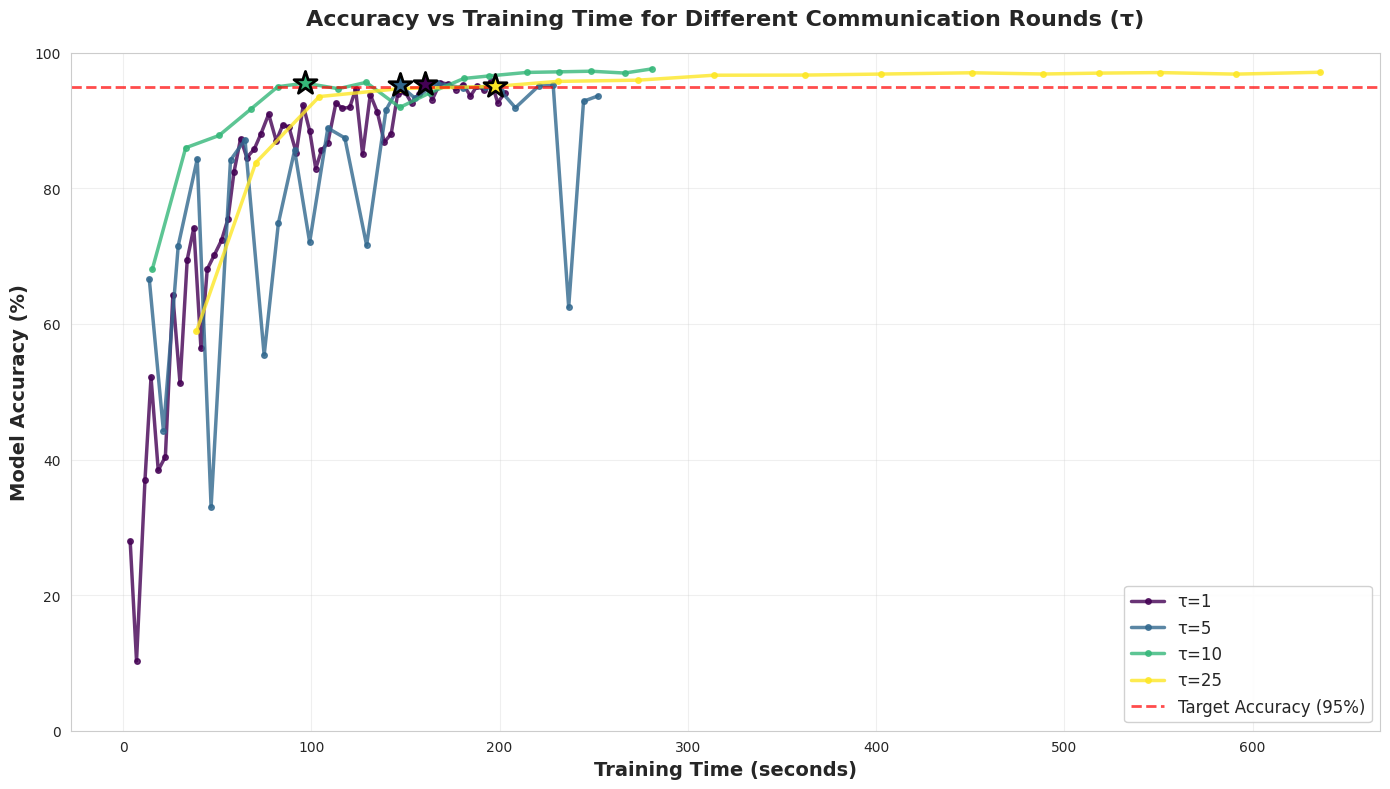

✓ Saved: accuracy_vs_time.png


In [ ]:
# Plot 1: Accuracy vs Total Time (Computation + Network) for different τ values
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(all_results)))

for idx, (key, results) in enumerate(sorted(all_results.items(),
                                             key=lambda x: int(x[0].split('_')[1]))):
    tau = results['tau']

    # Calculate total time (computation + network) at each round
    total_time_history = [
        results['computation_cost_history'][i] + results['network_time_history'][i]
        for i in range(len(results['round_history']))
    ]
    accuracy_history = results['accuracy_history']

    ax.plot(total_time_history, accuracy_history,
           marker='o', markersize=4, linewidth=2.5,
           label=f'τ={tau}', color=colors[idx], alpha=0.8)

    # Mark convergence point
    if results['convergence_round'] is not None:
        conv_idx = results['convergence_round'] - 1
        if conv_idx < len(total_time_history):
            ax.scatter(total_time_history[conv_idx], accuracy_history[conv_idx],
                      s=300, marker='*', color=colors[idx],
                      edgecolors='black', linewidths=2, zorder=5)

# Add 90% accuracy threshold line
ax.axhline(y=90, color='red', linestyle='--', linewidth=2,
          label='Target Accuracy (90%)', alpha=0.7)

ax.set_xlabel('Total Time (Computation + Network) (seconds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Model Accuracy (%)', fontsize=14, fontweight='bold')
ax.set_title('Accuracy vs Total Time for Different Communication Rounds (τ)',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='lower right', fontsize=12, framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 100])

plt.tight_layout()
plt.savefig('accuracy_vs_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: accuracy_vs_time.png")

/tmp/ipython-input-2407686712.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12)


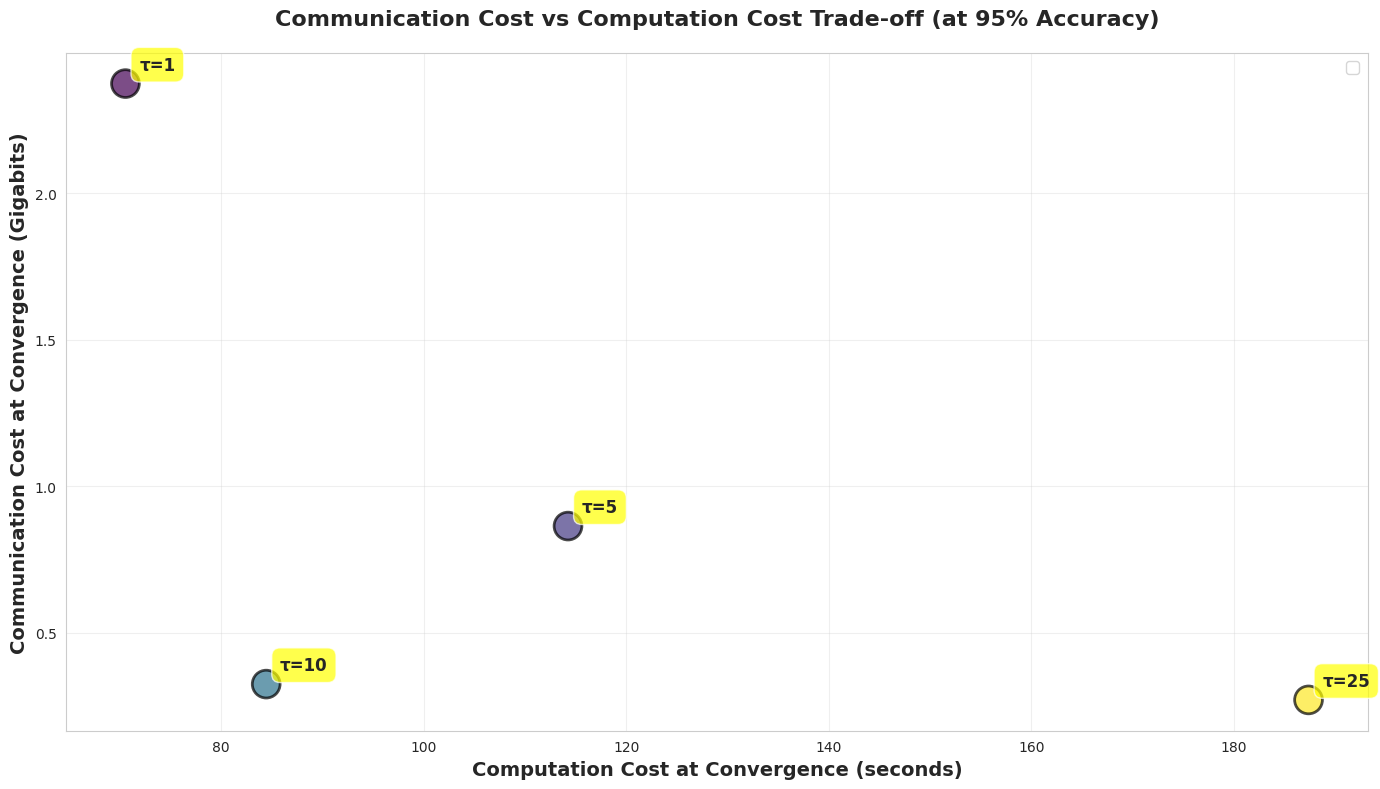

✓ Saved: communication_vs_computation.png


In [ ]:
# Plot 2: Communication Cost vs Total Time (at Convergence)
fig, ax = plt.subplots(figsize=(14, 8))

tau_vals = []
comm_costs = []
total_times = []

for key, results in sorted(all_results.items(),
                          key=lambda x: int(x[0].split('_')[1])):
    if results['convergence_round']:
        conv_idx = results['convergence_round'] - 1

        tau_vals.append(results['tau'])
        comm_costs.append(results['communication_cost_history'][conv_idx] / 1e9)  # Convert to Gb

        # Total time = computation + network at convergence
        comp_time = results['computation_cost_history'][conv_idx]
        network_time = results['network_time_history'][conv_idx]
        total_time = comp_time + network_time
        total_times.append(total_time)

# Create scatter plot
scatter = ax.scatter(total_times, comm_costs,
                    c=tau_vals, cmap='viridis',
                    s=400, alpha=0.7, edgecolors='black', linewidth=2)

# Add labels for each point
for i, tau in enumerate(tau_vals):
    ax.annotate(f'τ={tau}',
               (total_times[i], comm_costs[i]),
               xytext=(10, 10), textcoords='offset points',
               fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('τ (Communication Rounds)', fontsize=12, fontweight='bold')

# Add trend line
if len(total_times) >= 2:
    z = np.polyfit(total_times, comm_costs, 1)
    p = np.poly1d(z)
    x_trend = np.linspace(min(total_times), max(total_times), 100)
    ax.plot(x_trend, p(x_trend), "r--", alpha=0.5, linewidth=2, label='Trend line')

ax.set_xlabel('Total Time at Convergence (Computation + Network) (seconds)', fontsize=14, fontweight='bold')
ax.set_ylabel('Communication Cost at Convergence (Gigabits)', fontsize=14, fontweight='bold')
ax.set_title('Communication Cost vs Total Time Trade-off',
            fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('communication_vs_total_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: communication_vs_total_time.png")

## 6. Summary Table

In [ ]:
print("\n" + "="*120)
print("SUMMARY TABLE: Communication Efficiency Analysis (at Convergence)")
print("="*120)
print(f"{'τ':<6} {'Conv. Round':<13} {'Comp Time (s)':<15} {'Network Time (s)':<18} "
      f"{'Total Time (s)':<16} {'Comm (Gb)':<12} {'Acc (%)':<10} {'Speedup':<10}")
print("-"*120)

baseline_total = None

for key, results in sorted(all_results.items(),
                          key=lambda x: int(x[0].split('_')[1])):
    tau = results['tau']
    conv_round = results['convergence_round']

    if conv_round:
        conv_idx = conv_round - 1

        # Get values at convergence
        comp_time = results['computation_cost_history'][conv_idx]
        network_time = results['network_time_history'][conv_idx]
        total_time = comp_time + network_time
        comm_cost = results['communication_cost_history'][conv_idx] / 1e9
        acc = results['accuracy_history'][conv_idx]

        # Calculate speedup vs baseline (τ=1)
        if baseline_total is None:
            baseline_total = total_time
            speedup = "1.00×"
        else:
            speedup_val = baseline_total / total_time
            speedup = f"{speedup_val:.2f}×"

        print(f"{tau:<6} {conv_round:<13} {comp_time:<15.1f} {network_time:<18.1f} "
              f"{total_time:<16.1f} {comm_cost:<12.3f} {acc:<10.2f} {speedup:<10}")
    else:
        print(f"{tau:<6} {'N/A':<13} {'N/A':<15} {'N/A':<18} "
              f"{'N/A':<16} {'N/A':<12} {'N/A':<10} {'N/A':<10}")

print("="*120)
print("\nKey Insights:")
print("  - Computation time is similar across all τ (same total local training)")
print("  - Network time decreases with higher τ (fewer communication rounds)")
print("  - Total time speedup shows the real benefit of higher τ!")
print("="*120)


SUMMARY TABLE: Communication Efficiency Analysis (at Convergence)
τ        Conv. Round     Time at Conv (s)   Comm at Conv (Gb)  Comp at Conv (s) Acc at Conv (%)
------------------------------------------------------------------------------------------
1        44              160.62             2.37               70.55           95.37          
5        16              147.03             0.86               114.25          95.19          
10       6               96.64              0.32               84.45           95.53          
25       5               197.58             0.27               187.37          95.04          


## 7. Download Results

Save all results to JSON and download the plots.

In [ ]:
# Save results to JSON
with open('all_results.json', 'w') as f:
    json_results = {}
    for key, results in all_results.items():
        json_results[key] = {
            k: [float(v) if isinstance(v, (np.floating, np.integer)) else v
                for v in val] if isinstance(val, list) else val
            for k, val in results.items()
        }
    json.dump(json_results, f, indent=2)

print("✓ Results saved to 'all_results.json'")
print("✓ Plots saved: 'accuracy_vs_time.png' and 'communication_vs_computation.png'")
print("\nYou can download these files from the Colab file browser (left sidebar).")

# For Google Drive (optional - uncomment if you want to save to Drive)
# from google.colab import drive
# drive.mount('/content/drive')
# !cp all_results.json accuracy_vs_time.png communication_vs_computation.png /content/drive/MyDrive/

✓ Results saved to 'all_results.json'
✓ Plots saved: 'accuracy_vs_time.png' and 'communication_vs_computation.png'

You can download these files from the Colab file browser (left sidebar).
